### Evaluación de Clasificadores Basados en Distancia y Máxima Verosimilitud

Iniciamos la fase de modelado supervisado enfrentando dos enfoques teóricos distintos sobre la partición de prueba (20% de los datos):

1.  **K-Nearest Neighbors (KNN):** Un método no paramétrico y geométrico que clasifica por votación de vecindad local. Es altamente dependiente del escalado estándar previo.
2.  **Regresión Logística Multinomial:** Un modelo paramétrico lineal que utiliza la función *Softmax* para asignar probabilidades a cada una de las 6 especies mediante la optimización de la función de verosimilitud.

*   **Reproducibilidad Asegurada:** El uso de una semilla aleatoria (`random_state=42`) en todas las etapas críticas garantiza que los vectores de soporte y las fronteras de decisión se mantengan idénticos en cualquier entorno de ejecución.


In [1]:
import os
import pandas as pd
import numpy as np

# Cargar las matrices escaladas (para KNN, Logística, SVM, LDA, etc.)
X_train_scaled = pd.read_csv('../Datos/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../Datos/X_test_scaled.csv')

# Cargar las matrices sin escalar (para Árboles, Bagging, Boosting)
X_train_raw = pd.read_csv('../Datos/X_train_raw.csv')
X_test_raw = pd.read_csv('../Datos/X_test_raw.csv')

# Cargar las etiquetas 
y_train = pd.read_csv('../Datos/y_train.csv').values.ravel()
y_test = pd.read_csv('../Datos/y_test.csv').values.ravel()

print(f"Datos importados correctamente. Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Datos importados correctamente. Train: (13768, 17), Test: (3442, 17)


### Evaluación de Desempeño mediante Accuracy y Curvas ROC Multiclase

Para validar el comportamiento de nuestros primeros clasificadores supervisados, implementamos una estrategia de evaluación basada en dos métricas fundamentales de la teoría estadística:

1.  **Accuracy (Exactitud Global):** Mide la proporción de predicciones correctas sobre el total de la muestra de prueba. Al haber balanceado previamente las clases a un tope de 3,500 registros, esta métrica se vuelve altamente confiable y libre del sesgo del Yaguareté.
2.  **Curvas ROC y Área Bajo la Curva (AUC):** Dado el entorno multiclase (6 especies), aplicamos el enfoque *One-vs-Rest* (OvR). El AUC nos permite evaluar qué tan eficiente es cada modelo para discriminar una especie en particular frente a todo el resto del ecosistema, donde un valor de 1.0 representa una separación perfecta de las distribuciones de probabilidad y 0.50 un comportamiento puramente aleatorio.


c:\Users\TieriTina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy Global - KNN: 0.8077
Accuracy Global - Regresión Logística: 0.7115



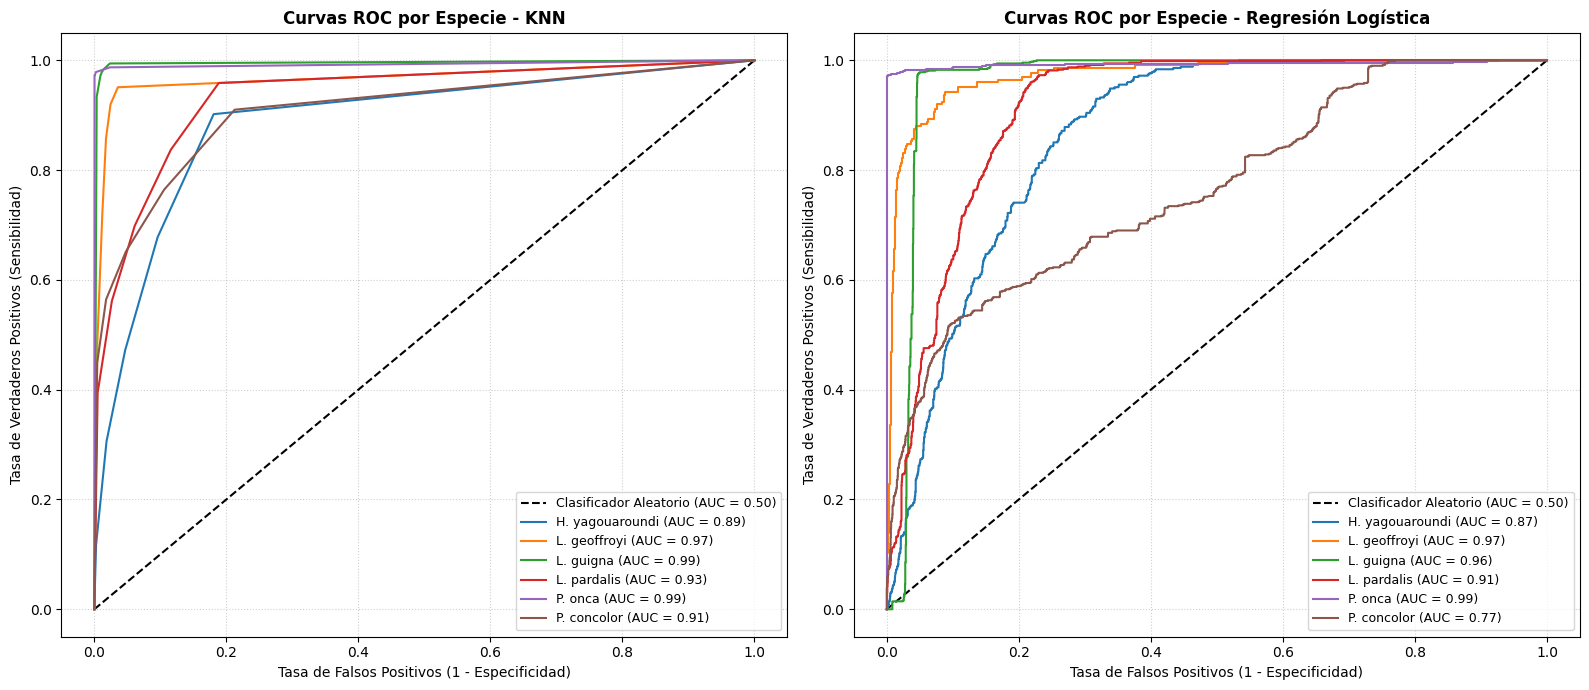

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Entrenar los dos modelos 
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42).fit(X_train_scaled, y_train)

# Predecir clases y obtener probabilidades 
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)

# Calcular Accuracy
print(f"Accuracy Global - KNN: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Accuracy Global - Regresión Logística: {accuracy_score(y_test, y_pred_log):.4f}\n")

# CÁLCULO DE LA CURVA ROC MULTICLASE (Estrategia One-vs-Rest)
# Binarizamos las etiquetas de prueba 
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])
n_classes = 6
especies_nombres = ['H. yagouaroundi', 'L. geoffroyi', 'L. guigna', 'L. pardalis', 'P. onca', 'P. concolor']

# Configurar el gráfico de las Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, model_prob, model_name, ax in zip([0, 1], [y_prob_knn, y_prob_log], ['KNN', 'Regresión Logística'], axes):
    ax.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)')
    for cl in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cl], model_prob[:, cl])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{especies_nombres[cl]} (AUC = {roc_auc:.2f})')
    
    ax.set_title(f'Curvas ROC por Especie - {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Diagnóstico de Errores mediante Matrices de Confusión

La matriz de confusión nos permite auditar los aciertos y las desviaciones de los clasificadores en la diagonal principal (donde se cruzan la realidad y la predicción):

*   **Análisis del sesgo del Puma (_Puma concolor_):** El mapa de calor revela por qué el Puma tuvo el AUC más bajo (0.77 en Logística). Al ser un felino generalista con una enorme dispersión geográfica, sus coordenadas se superponen frecuentemente con las del Ocelote y el Yaguareté, causando que la IA confunda sus registros.
*   **Aislamiento Exitoso de la Güiña (_Leopardus guigna_):** La diagonal muestra un conteo de errores casi nulo para esta especie. Esto confirma que su restricción geográfica estricta (Chile/Argentina) actúa como un fuerte clasificador geométrico natural.


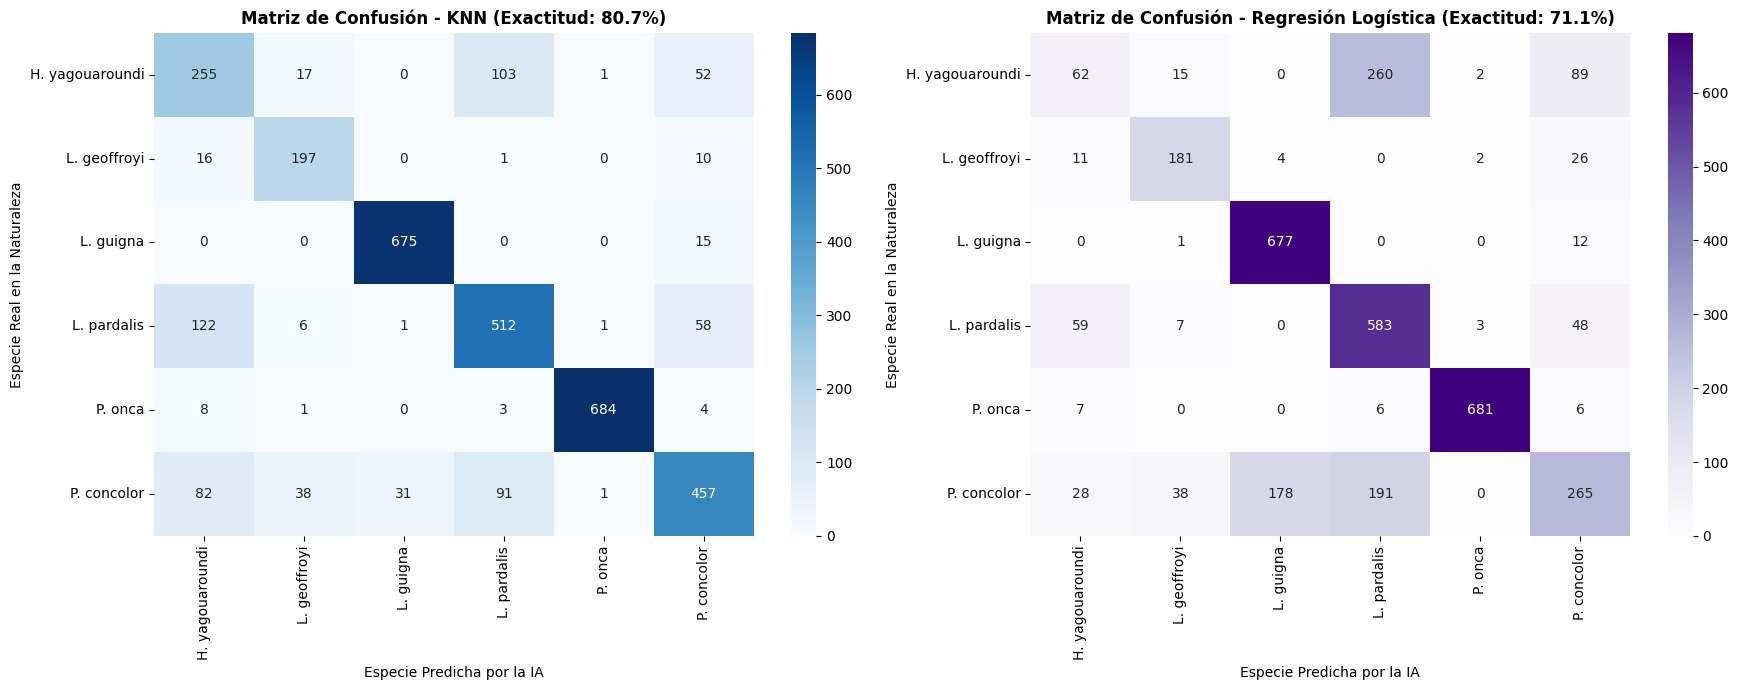

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular las matrices de confusión para ambos modelos
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_log = confusion_matrix(y_test, y_pred_log)

# Lista de nombres cortos de las especies para los ejes
especies_nombres = ['H. yagouaroundi', 'L. geoffroyi', 'L. guigna', 'L. pardalis', 'P. onca', 'P. concolor']

# Configurar la figura con dos mapas de calor en paralelo
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz KNN
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Blues", 
    xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[0]
)
axes[0].set_title('Matriz de Confusión - KNN (Exactitud: 80.7%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Especie Predicha por la IA')
axes[0].set_ylabel('Especie Real en la Naturaleza')

# Matriz Regresión Logística
sns.heatmap(
    cm_log, annot=True, fmt="d", cmap="Purples", 
    xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[1]
)
axes[1].set_title('Matriz de Confusión - Regresión Logística (Exactitud: 71.1%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Especie Predicha por la IA')
axes[1].set_ylabel('Especie Real en la Naturaleza')

plt.tight_layout()
plt.show()


### Análisis Diagnóstico de Errores en la Matriz de Confusión

El análisis minucioso de las clasificaciones incorrectas nos permite entender las limitaciones físicas y ecológicas de los modelos:

1.  **La Claridad del Yaguareté (*P. onca*) y la Güiña (*L. guigna*):** En KNN, el Yaguareté alcanza el pico más alto de la diagonal con **684 aciertos**, seguido de cerca por la Güiña con **675**. Esto confirma que sus firmas geoespaciales son drásticamente distintas al resto. Prácticamente ningún animal es confundido con un Yaguareté.
2.  **El Solapamiento Crítico (Ocelote vs. Yaguarundí):** En la Regresión Logística vemos un error severo: **260 registros de Yaguarundí (*H. yagouaroundi*) fueron clasificados erróneamente como Ocelotes (*L. pardalis*)**. En KNN el error también es alto (103). Biológicamente esto es fascinante, ya que ambas especies comparten exactamente el mismo ecosistema de bosques tropicales bajos y llanos, lo que causa que sus coordenadas y altitudes colisionen en el espacio de características.
3.  **La Crisis del Puma (*P. concolor*):** El Puma es el gran dolor de cabeza de ambos modelos. En la Regresión Logística, solo **265 pumas fueron bien clasificados**, mientras que **191 se confundieron con Ocelotes** y **178 con Güiñas**. Al ser un depredador que habita desde las cumbres andinas hasta las selvas, su dispersión genera una varianza enorme que los límites lineales de la Regresión Logística no logran capturar.
